# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from qick import *

from qick.asm_v2 import QickSpan, QickSweep1D

from QickworkspaceV2 import BaseExperiment

soc, soccfg = BaseExperiment.connect_pyro4(
    ns_host="192.168.10.82",
    ns_port=8888,
    proxy_name="myqick",
    data_path=r"D:\Labber_Data\Jay\harmonized",
)

print(soccfg)

QICK library version mismatch: 0.2.381 remote (the board), 0.2.405 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_1051f78521bc454089cfc53aaf8f04e1@192.168.10.82:37807
[BaseExperiment] Session activated: QICK@192.168.10.82:8888/myqick, data_path='D:\\Labber_Data\\Jay\\harmonized'
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Sun Aug 10 18:48:22 2025):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	ax

# Qubit Setting

In [2]:
from QickworkspaceV2.tools.system_tool import ExperimentConfig
from QickworkspaceV2.config.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

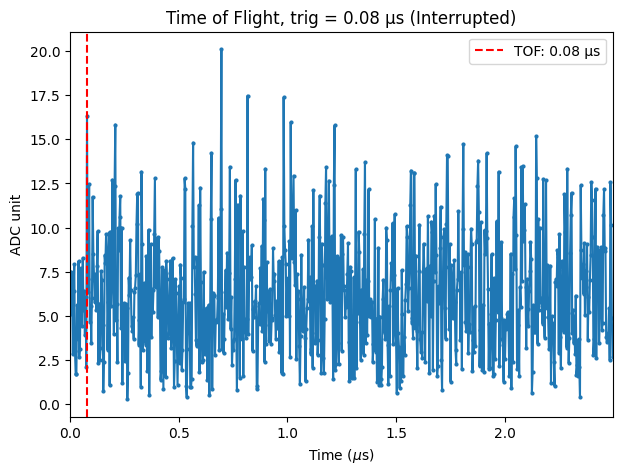

ExperimentData(type='s001_tof', id='20260824T060214958136Z-ANW49KFTVXPAF', quality=no_information, status=interrupted)

In [3]:
from QickworkspaceV2.experiments.setup import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        "res_sigma": 0.05,
        "res_freq_ge": 6000,
        "ro_length": 2.5,
        "res_length": 1.7,
        "res_gain_ge": 0.01,
        "res_ch": 0,
        "cheek_e": False,
        "check_f": False,
        "relax_delay": 1,
    }
)

tof = TOF(run_cfg)
tof.run(1000)
# tof.saveLabber(qubit)

# Instrument Setting

Use `BaseInstrumentManager` to connect Yoko flux sources and RF sources. Fill in your lab addresses before running.

In [3]:
# from QickworkspaceV2.instruments import BaseInstrumentManager

# inst = BaseInstrumentManager()

# # Fill these before running. SGS100A/MG3692 accept either plain IP or full VISA string.
# Q1_FLUX_ADDR = "USB0::0x0B21::0x0039::91S522309::INSTR"
# Q2_FLUX_ADDR = ""  # Optional second Yoko; leave empty to skip
# MG3692_ADDR = "192.168.10.182"

# Q1_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}
# Q2_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}

# q1_flux = inst.add_yoko(
#     "q1_flux",
#     Q1_FLUX_ADDR,
#     limits=Q1_FLUX_LIMITS,
#     current_ramp_step=1e-8,
#     voltage_ramp_step=1e-5,
#     ramp_interval=0.01,
# )

# q2_flux = None
# if Q2_FLUX_ADDR:
#     q2_flux = inst.add_yoko(
#         "q2_flux",
#         Q2_FLUX_ADDR,
#         limits=Q2_FLUX_LIMITS,
#         current_ramp_step=1e-8,
#         voltage_ramp_step=1e-5,
#         ramp_interval=0.01,
#     )

# lo = inst.add_mg3692("pump", MG3692_ADDR)

# inst.status

In [4]:
# inst.set_value("q1_flux", 0.0, mode="current")

## Instrument Quick Checks

Read-only checks plus optional write examples. The write examples are commented out intentionally.

In [6]:
# inst.help()
# inst.limits()
# inst.value("q1_flux")
# inst.ramp("q1_flux")

# Optional Yoko set test. tqdm will show target/current value and remaining time.
# inst.set_value("q1_flux", 0.0, mode="current")

# Optional MG3692 LO setup. Confirm safe frequency/power before uncommenting.
# inst.set(pump", "frequency", 6.0e9)
# inst.set_value("lo", -40)
# inst.off("pump")
# inst.status

# GE State

## Resonator OneTone

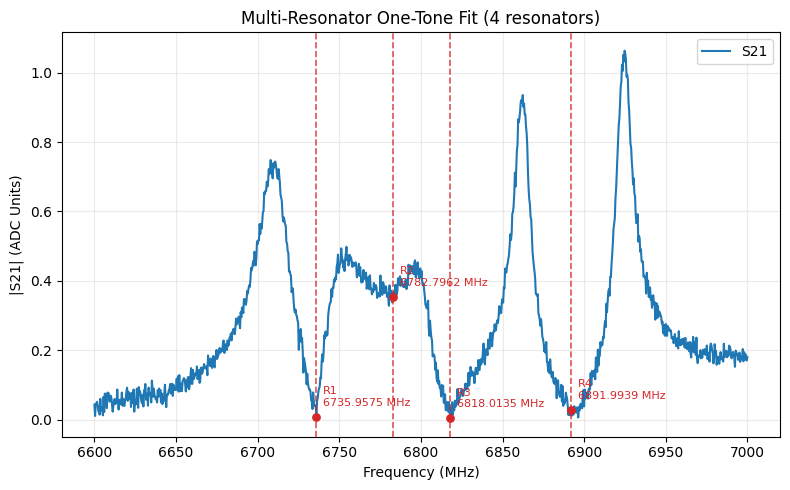

Data saved to D:\Labber_Data\Jay\harmonized\2026\08\Data_0824\broadband_resonator_spectrum_004.hdf5


'D:\\Labber_Data\\Jay\\harmonized\\2026\\08\\Data_0824\\broadband_resonator_spectrum_004.hdf5'

In [8]:
from QickworkspaceV2.experiments.resonator import BroadbandResonatorSpec

START_FREQ = 6600  # [MHz]
STOP_FREQ = 7000 #[MHz]



STEPS = 1001
config_all.update('threshold', None)
config_all.update("res_gain_ge", 1, q_index=qubit)
config_all.update("res_sigma", 0.01, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = BroadbandResonatorSpec(run_cfg)
result = onetone.run(py_avg=10, count=4)
freq = onetone.resonator_freqs

onetone.saveLabber(qubit, yoko_value=None, config_all=config_all, filename_mode="sequential")

Experiment interrupted at 8 averages. Fit is based on partial data.


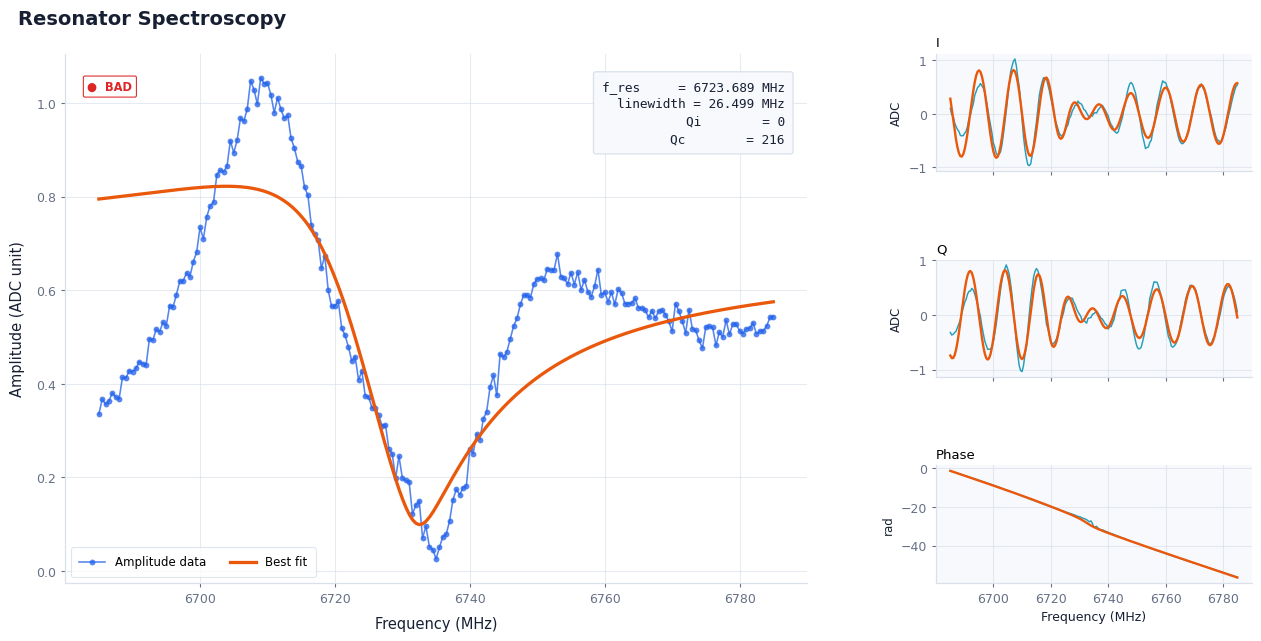

Data saved to D:\Labber_Data\Jay\harmonized\2026\08\Data_0824\s002_res_ge_Q1_20260824T060316417603Z-7FC3G4EZZ1CJG.hdf5


'D:\\Labber_Data\\Jay\\harmonized\\2026\\08\\Data_0824\\s002_res_ge_Q1_20260824T060316417603Z-7FC3G4EZZ1CJG.hdf5'

In [7]:
from QickworkspaceV2.experiments.resonator import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 5  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 5  # [MHz]

START_FREQ = 6735-50  # [MHz]
STOP_FREQ = 6735 + 50  # [MHz]


STEPS = 201
config_all.update('threshold', None)
config_all.update("res_gain_ge", 0.3, q_index=qubit)
config_all.update("res_sigma", 0.1)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
onetone.run(py_avg=50, solve_type="hm")
onetone.plot()
## update value ##
config_all.update("res_freq_ge", onetone.result["f_res[MHz]"], q_index=qubit)
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

## Resonator OneTone Flux

Sweep resonator frequency while stepping a Yoko current through `BaseInstrumentManager`. Yoko sweeps now use the manager-registered instrument name.

In [17]:
# from QickworkspaceV2.experiments.resonator import ResonatorSpecFlux

# YOKO_NAME = "q1_flux"
# YOKO_MODE = "current"

# CENTER_FREQ = config_all.get_qubit(qubit)["res_freq_ge"]  # MHz
# FREQ_SPAN = 100  # MHz
# START_FREQ = CENTER_FREQ - FREQ_SPAN / 2
# STOP_FREQ = CENTER_FREQ + FREQ_SPAN / 2
# STEPS = 101

# FLUX_START = -0.5e-3  # A
# FLUX_STOP = 0.5e-3    # A
# FLUX_STEPS = 11
# yoko_values = np.linspace(FLUX_START, FLUX_STOP, FLUX_STEPS)

# config_all.update("res.res_gain_ge", 0.4, q_index=qubit)
# run_cfg = config_all.get_qubit(qubit)
# run_cfg.update(
#     [
#         ("steps", STEPS),
#         ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
#         ("relax_delay", 0),
#         ("yoko_value", yoko_values),
#     ]
# )

# onetone_flux = ResonatorSpecFlux(run_cfg)
# result_flux = onetone_flux.run(
#     py_avg=5,
#     instrument_manager=inst,
#     yoko_name=YOKO_NAME,
#     yoko_value=yoko_values,
#     yoko_mode=YOKO_MODE,
#     show_final_plot=True,
# )

# # onetone_flux.saveLabber(qubit, config_all=config_all)

## OneTone PunchOut

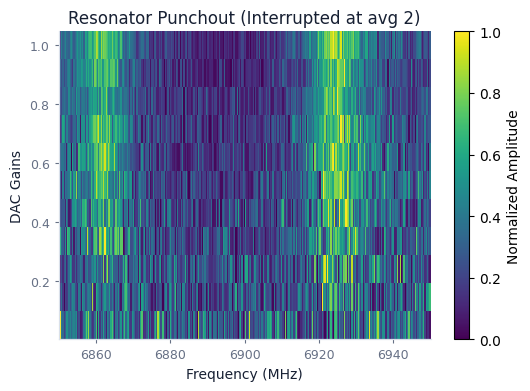

Experiment interrupted at 2 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\test\2026\08\Data_0824\s002b_res_ge_punchout_Q1_20260824T051430967553Z-8P5V0SW0FGWF3.hdf5


'D:\\Labber_Data\\Jay\\test\\2026\\08\\Data_0824\\s002b_res_ge_punchout_Q1_20260824T051430967553Z-8P5V0SW0FGWF3.hdf5'

In [39]:
from QickworkspaceV2.experiments.resonator import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]
START_FREQ = 6850  # [MHz]
STOP_FREQ = 6950  # [MHz]

STEPS_freq = 301

START_gain = 0.05
STOP_gain = 1
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
        ("relax_delay", 0),
        ('threshold', None)
    ]
)
punchout = Punchout(run_cfg)
punchout.run(py_avg=100, show_final_plot=True)
punchout.saveLabber(qubit, config_all=config_all)

## Dispersive Shift

Chi SNR batches:   0%|          | 0/10 [00:00<?, ?it/s]

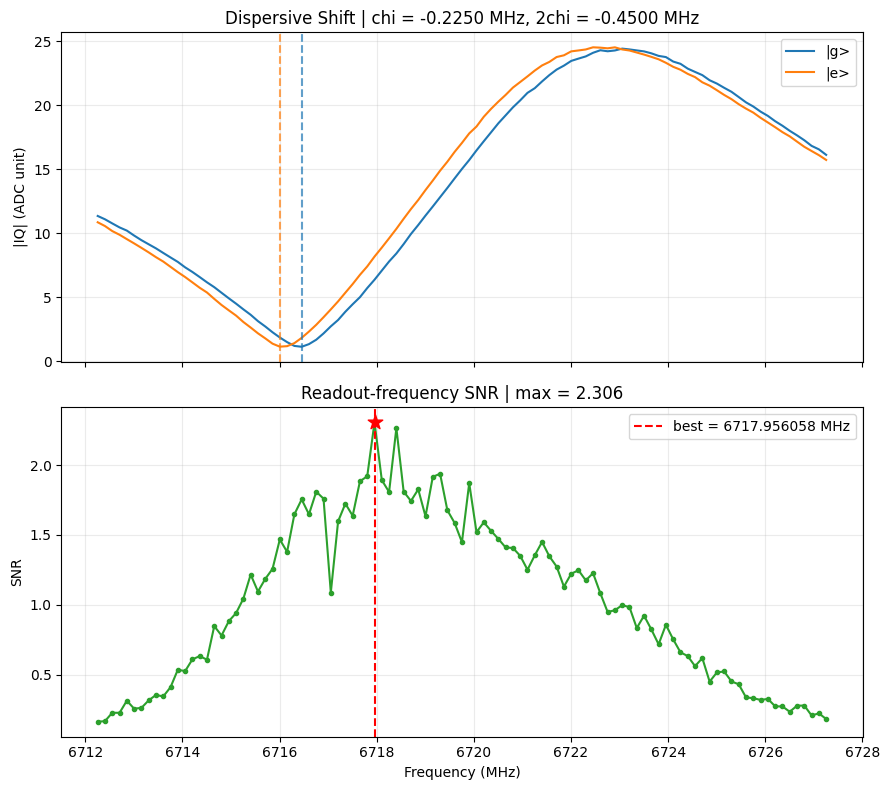

Best readout frequency: 6717.956058311462
Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\resonator_chi_ge_Q1_20260807T012408952721Z-E5WGNB8D2NA81.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\resonator_chi_ge_Q1_20260807T012408952721Z-E5WGNB8D2NA81.hdf5'

In [11]:
from QickworkspaceV2.experiments.resonator import Chi

CENTER_FREQ = config_all.get_qubit(qubit)["res_freq_ge"]  # [MHz]
FREQ_SPAN = 15  # [MHz]
STEPS = 101

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", CENTER_FREQ - FREQ_SPAN / 2, CENTER_FREQ + FREQ_SPAN / 2)),
        ("relax_delay", 200),
        ("threshold", None),
        ("snr_shots", 100)
    ]
)

chi = Chi(run_cfg)
result, best_freq = chi.run(10, plot=True, return_best_freq=True,)
print("Best readout frequency:", best_freq)
config_all.update("res_freq_ge", best_freq, q_index=qubit)
chi.saveLabber(qubit, config_all=config_all)

## CKP

  0%|          | 0/65100 [00:00<?, ?it/s]

  0%|          | 0/65100 [00:00<?, ?it/s]

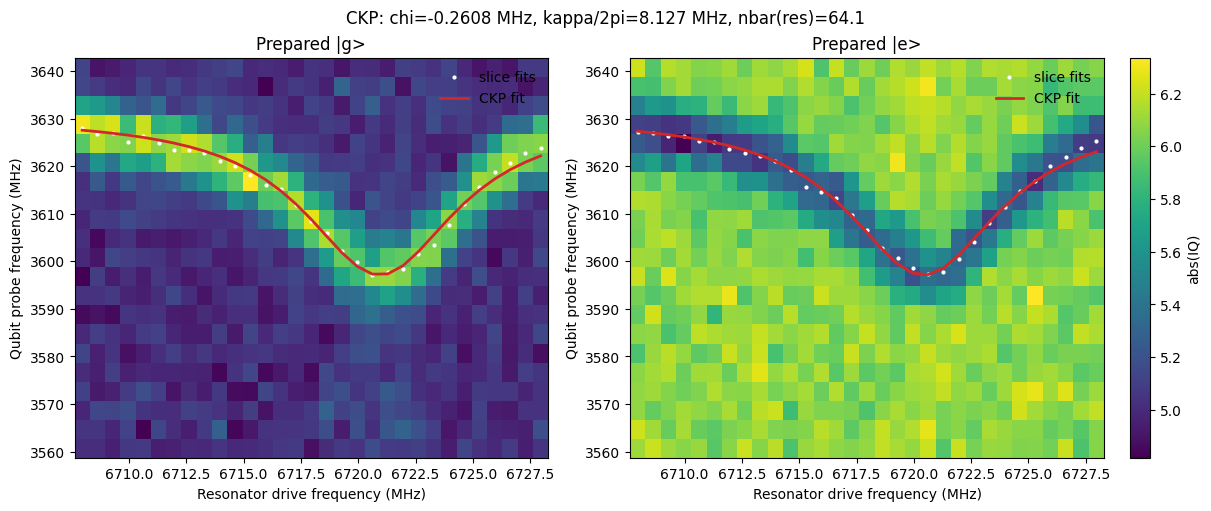

In [18]:
from qick.asm_v2 import QickSweep1D
from QickworkspaceV2 import CKP

cfg = config_all.get_qubit(qubit)

cfg.update({
    "res_gain_ge": 0.1,
    "ckp_res_steps": 31,
    "ckp_qb_steps": 21,

    "ckp_res_freq": QickSweep1D(
        "ckp_resfreqloop",
        cfg["res_freq_ge"] - 10,
        cfg["res_freq_ge"] + 10,
    ),
    "ckp_qb_freq": QickSweep1D(
        "ckp_qbfreqloop",
        cfg["qb_freq_ge"] - 70,
        cfg["qb_freq_ge"] + 10,
    ),

    "ckp_res_gain": cfg["res_gain_ge"],
    "ckp_fit_channel": "abs",
})

result = CKP(cfg).run(
    py_avg=1,
    plot_analysis=True,
)

## Qubit Spectrum ge

Experiment interrupted at 24 averages. Fit is based on partial data.


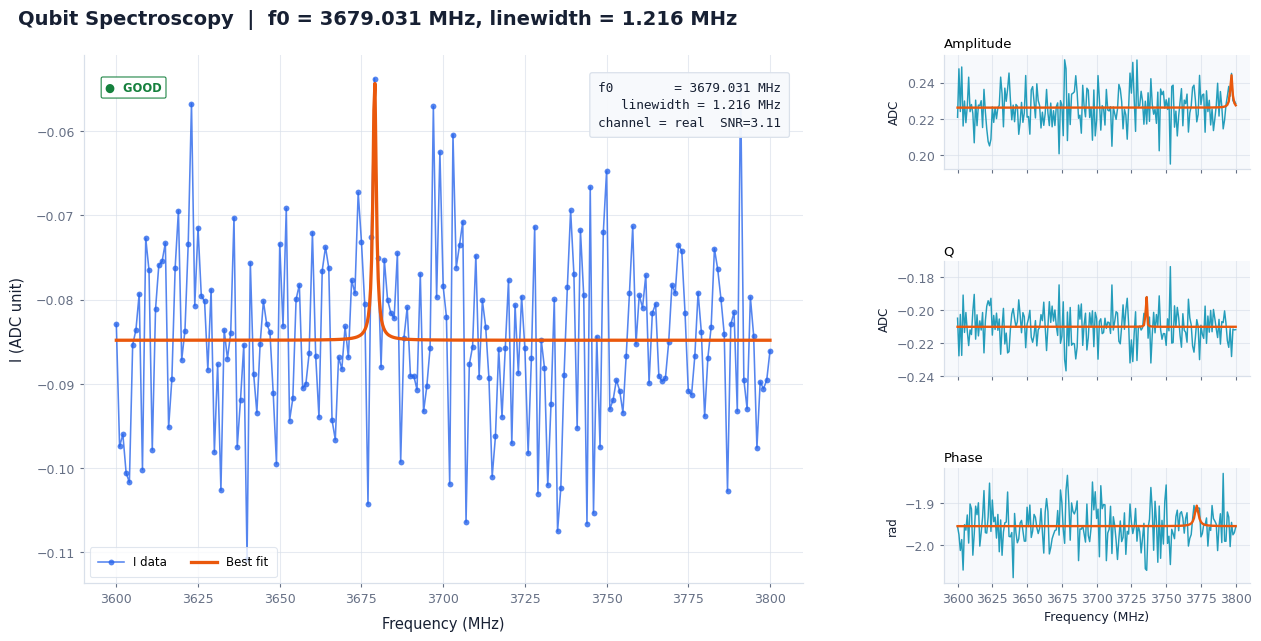

In [35]:
from QickworkspaceV2.experiments.qubit_ge import QubitSpec

center = 3700
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

config_all.update("qb_ch", 1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 1),
        ("qb_flat_top_length_ge", 1),
        ("relax_delay", 10),
        ("nqz_qb", 1),
    ]
)

spectrum_ge = QubitSpec(run_cfg)
spectrum_ge.run(50, plot_analysis=True)
f_ge = spectrum_ge.result["f0_MHz"]
config_all.update("qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb_mixer", f_ge, q_index=qubit)
# spectrum_ge.saveLabber(qubit, config_all=config_all)

### Fast flux spectrum

In [24]:
# from QickworkspaceV2.experiments.qubit_ge import QubitSpecFlux

# center = 5970
# SPAN = 50
# START_FREQ = center - SPAN  # [MHz]
# STOP_FREQ = center + SPAN  # [MHz]
# STEPS = 201

# START_GAIN = -1
# STOP_GAIN = 1
# STEPS_GAIN = 11

# config_all.update("qb_ch", 2, q_index=qubit)
# run_cfg = config_all.get_qubit(qubit)
# run_cfg.update(
#     [
#         ("steps", STEPS),
#         ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
#         ("qb_mixer", center),
#         ("qb_gain_ge", 0.3),
#         ("qb_flat_top_length_ge", 0.5),
#         ("relax_delay", 1),
#         ("nqz_qb", 2),
#         ("res_length", 3),
#         ("ro_length", 2.478),
#         ("res_gain_ge", 0.95),
#         ("flux_ch", 15),
#         ("flux_gain", QickSweep1D("fluxloop", START_GAIN, STOP_GAIN)),
#         ("steps_flux", STEPS_GAIN),
#         ("flux_length", 0.7),
#     ]
# )

# spectrumff_ge = QubitSpecFlux(run_cfg)
# spectrumff_ge.run(500, swap_xy=True, show_final_plot=True)

## Time Rabi ge

Experiment interrupted at 24 averages. Fit is based on partial data.


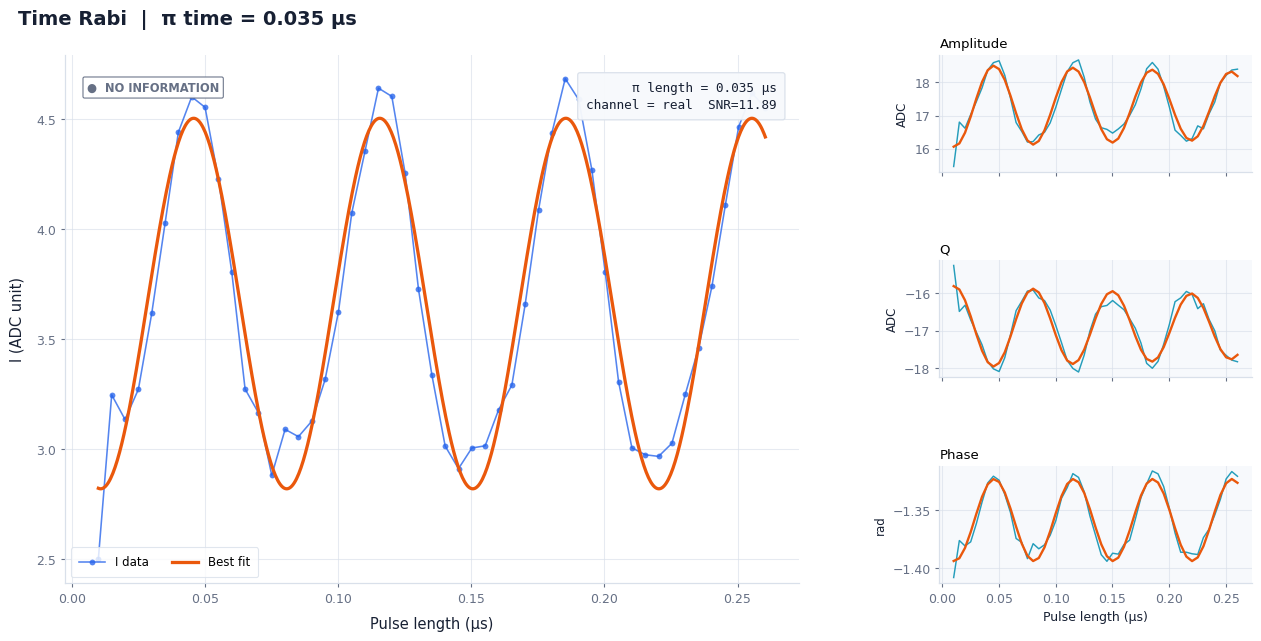

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s004_time_rabi_ge_Q3_20260806T222734854206Z-A3DPE178VGQYR.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s004_time_rabi_ge_Q3_20260806T222734854206Z-A3DPE178VGQYR.hdf5'

In [12]:
from QickworkspaceV2.experiments.qubit_ge import TimeRabi

config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 150, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.8),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.3)),
        ("steps", 51),
    ]
)

Trabi = TimeRabi(run_cfg)
Trabi.run(100, plot_analysis=True)
Trabi.saveLabber(qubit, config_all=config_all)

## Power Rabi ge

Experiment interrupted at 3 averages. Fit is based on partial data.


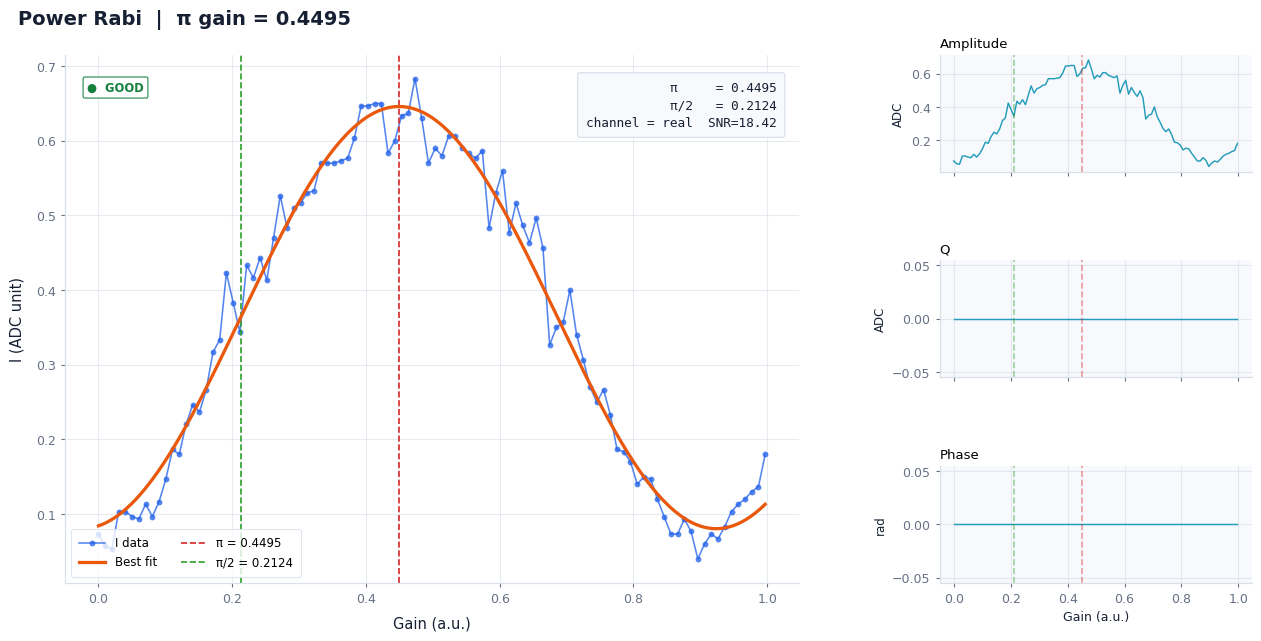

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s005_power_rabi_ge_Q3_20260807T020528522725Z-0ZFMEFEBRK3XX.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s005_power_rabi_ge_Q3_20260807T020528522725Z-0ZFMEFEBRK3XX.hdf5'

In [31]:
from QickworkspaceV2.experiments.qubit_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ge", 0.025, q_index=qubit)
config_all.update("nqz_qb", 1, q_index=qubit)
config_all.update("relax_delay", 200, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        # ("pulse_type", "drag"),
        # ("qb_flat_top_length_ge", 0.3),
    ]
)

prabi = PowerRabi(run_cfg)
prabi.run(10, plot_analysis=True)
pi_gain, pi2_gain = prabi.result["pi_gain"], prabi.result["pi2_gain"]
config_all.update("pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("pi2_gain_ge", pi2_gain, q_index=qubit)
prabi.saveLabber(qubit, config_all=config_all)

## Active Reset Power Rabi ge

  0%|          | 0/5 [00:00<?, ?it/s]

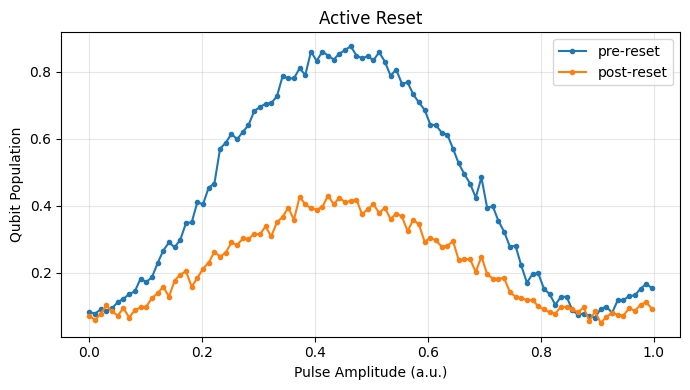

In [47]:
import matplotlib.pyplot as plt
import numpy as np

from QickworkspaceV2.experiments.qubit_ge import ActiveResetRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1.0  # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
THRESHOLD = float(run_cfg["threshold"])  # calibrated normalized I threshold
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        # Current Q1 single-shot has I_e > I_g, so excited shots are >= threshold.
        # Use "<" only after a calibration shows I_e < I_g.
        ("reset_excited_if", ">="),
        ("read_wait", 0.2),  # resync timing validated on current Q1 [us]
        ("feedback_slack", 0.05),  # resync runtime slack [us]
        ("reset_post_delay", 0.05),  # gap after conditional pi pulse [us]
        ("relax_delay", 150.0),
        # ("pulse_type", "drag"),
    ]
)

reset_rabi = ActiveResetRabi(run_cfg)
reset_result = reset_rabi.run(5)

# Threshold acquisition returns excited-state population for both readouts.
pre_reset = np.asarray(reset_rabi.pre_reset_population)
post_reset = np.asarray(reset_rabi.post_reset_population)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(reset_result.x_axis, pre_reset, "o-", ms=3, label="pre-reset")
ax.plot(reset_result.x_axis, post_reset, "o-", ms=3, label="post-reset")
ax.set(
    xlabel="Pulse Amplitude (a.u.)",
    ylabel="Qubit Population",
    title="Active Reset",
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

## Amplified Amplitude Error (AAE)


[PowerRabi] Optimal pi gain = 0.290017


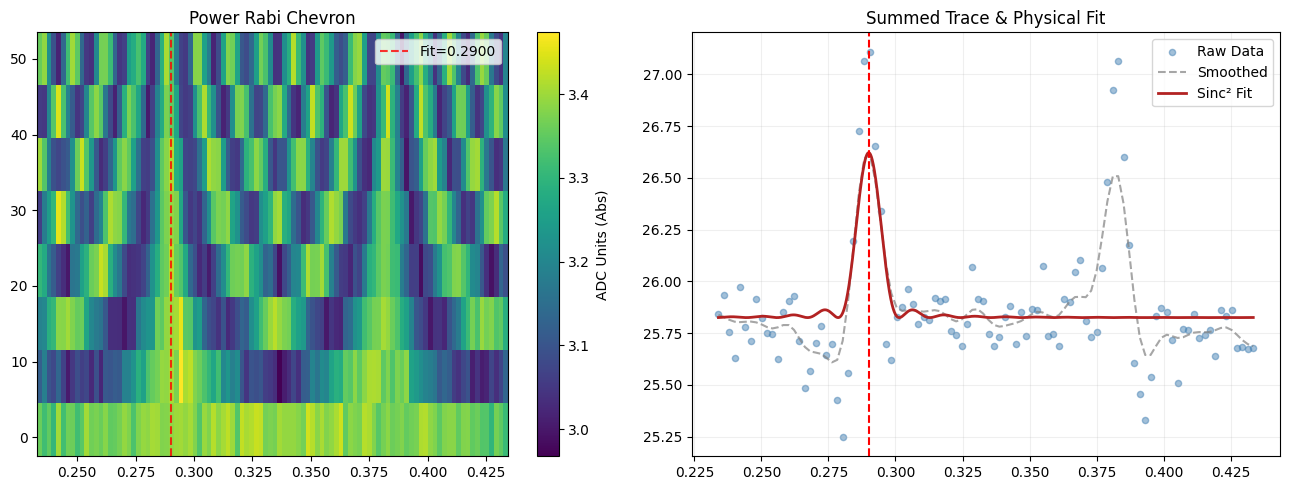

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import PowerRabiChevron

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
focus = run_cfg["pi_gain_ge"]
delta = run_cfg["pi_gain_ge"] - run_cfg["pi2_gain_ge"]
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", focus - delta, focus + delta)),
        # ("pulse_type", "drag"),
        ("iter_start", 1),
        ("iter_stop", 50),
        ("iter_step", 7),
        ('reps', 5)
    ]
)

aae = PowerRabiChevron(run_cfg)
result = aae.run(100)
# config_all.update("pi_gain_ge", result, q_index=qubit)
# config_all.update("pi2_gain_ge", result / 2, q_index=qubit)
# aae.saveLabber(qubit, config_all=config_all)

## Ramsey ge

Experiment interrupted at 8 averages. Fit is based on partial data.


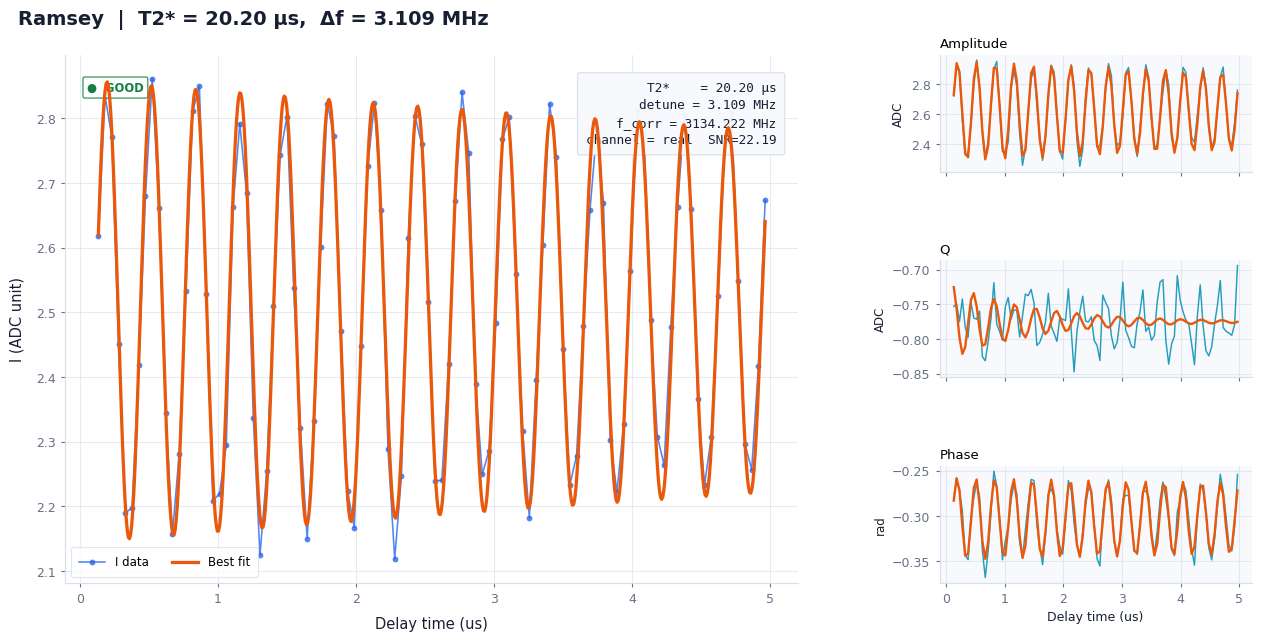

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s006_Ramsey_ge_Q3_20260807T020400055888Z-7WHW4YA4KXDYR.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s006_Ramsey_ge_Q3_20260807T020400055888Z-7WHW4YA4KXDYR.hdf5'

In [25]:
from QickworkspaceV2.experiments.coherence import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 5  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("virtual_detune", 1),
        # ("pulse_type", "drag"),
    ]
)


t2r = Ramsey(run_cfg)
t2r.run(20, plot_analysis=True)
t2r.saveLabber(qubit, config_all=config_all)

In [26]:
config_all.update("qb_freq_ge", t2r.correct_detune(), qubit)

over detune 2.10893MHz


## Spin Echo

Experiment interrupted at 3 averages. Fit is based on partial data.


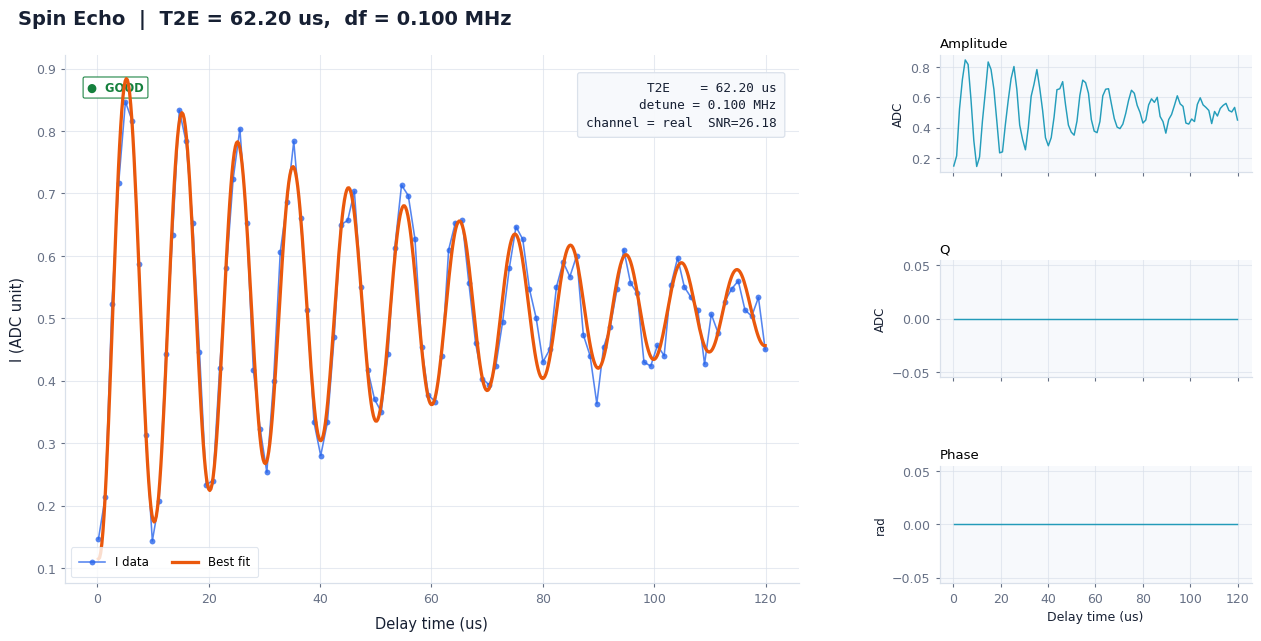

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s007_SpinEcho_ge_Q3_20260806T235953653274Z-18E5RA1MEERAK.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s007_SpinEcho_ge_Q3_20260806T235953653274Z-18E5RA1MEERAK.hdf5'

In [17]:
from QickworkspaceV2.experiments.coherence import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 120  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("virtual_detune", 0.1),
        # ("pulse_type", "drag")
    ]
)

t2e = SpinEcho(run_cfg)
t2e.run(100, plot_analysis=True)
t2e.saveLabber(qubit, config_all=config_all)

## T1 ge

Experiment interrupted at 2 averages. Fit is based on partial data.


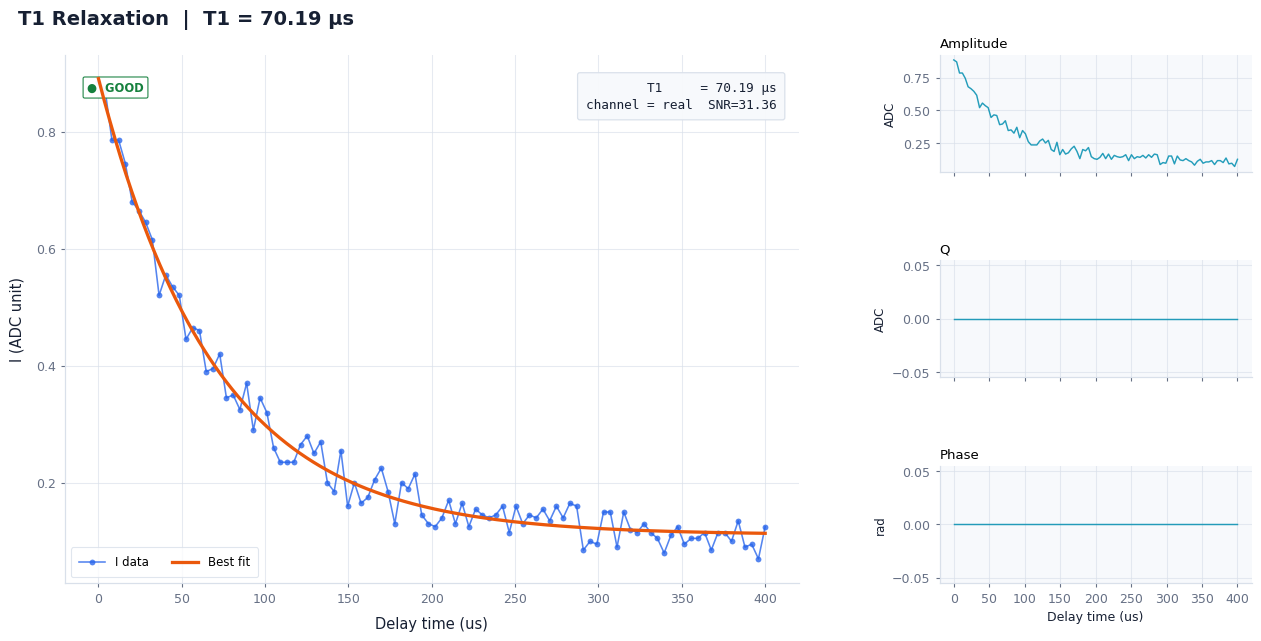

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s008_T1_ge_Q3_20260806T235938823773Z-6P742YWC3EPF7.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s008_T1_ge_Q3_20260806T235938823773Z-6P742YWC3EPF7.hdf5'

In [16]:
from QickworkspaceV2.experiments.coherence import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        # ("pulse_type", "drag"),
    ]
)

t1 = T1(run_cfg)
t1.run(10, plot_analysis=True)
t1.saveLabber(qubit, config_all=config_all)

## Single Shot gef

  0%|          | 0/10000 [00:00<?, ?it/s]

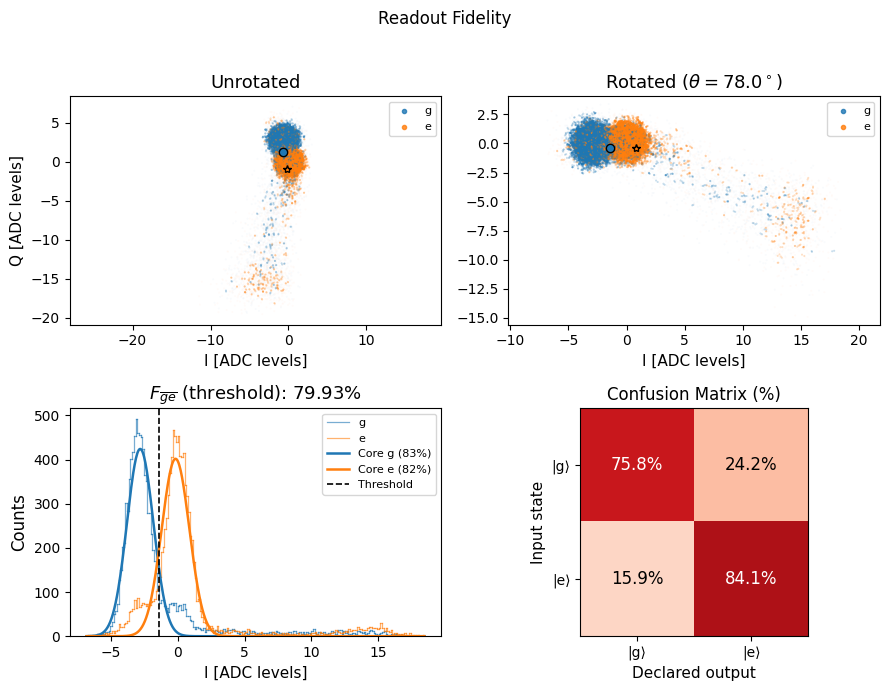

Rotation angle : 78.01 deg
Threshold Fid. : 79.930%
  g: core=83.2%  mean=-2.796  std=0.988
  e: core=82.3%  mean=-0.155  std=1.032
Thresholds     : ['-1.404']
Confusion Matrix (%):
 [[75.8 24.2]
 [15.9 84.1]]
Current data file: D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s000_singleshot_ge_Q3_001


In [42]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

### run single shot with optimized parameters ###
config_all.update("res_sigma", 0.005)
config_all.update("res_phase", 0, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

# run_cfg['pulse_type'] = "drag"
SHOT = 10000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update("res_phase", ssh_result[2], q_index=qubit)
ssh.saveLabber(qubit)

THRESHOLD=True
if THRESHOLD:
    config_all.update('threshold', ssh_result[1][0], q_index=qubit)

  0%|          | 0/10000 [00:00<?, ?it/s]

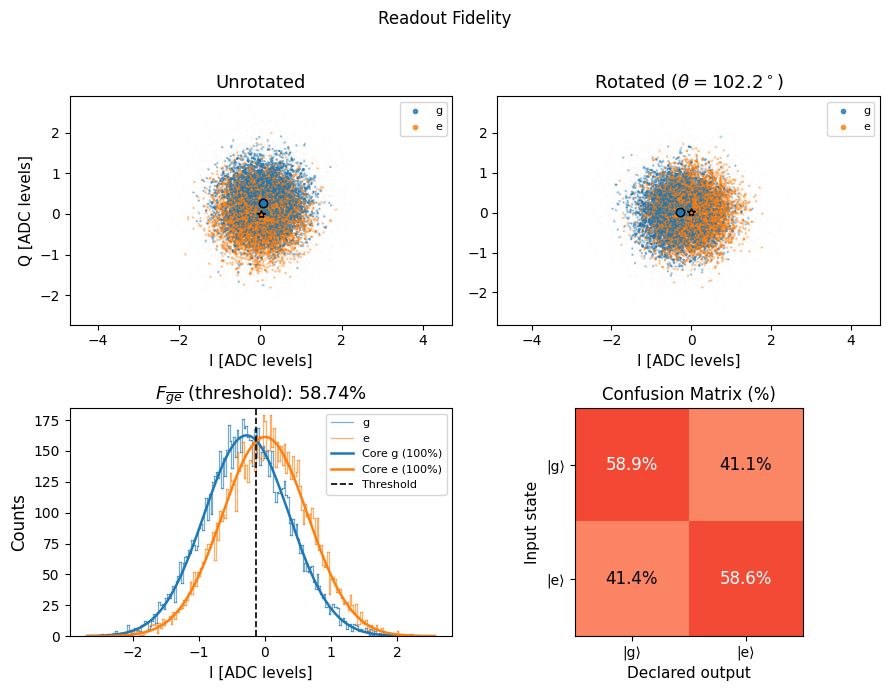

Rotation angle : 102.21 deg
Threshold Fid. : 58.735%
  g: core=99.5%  mean=-0.279  std=0.643
  e: core=99.7%  mean=-0.000  std=0.650
Thresholds     : ['-0.135']
Confusion Matrix (%):
 [[58.9 41.1]
 [41.4 58.6]]
Current data file: D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s000_singleshot_ge_Q3_001


In [39]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

### run single shot with optimized parameters ###
config_all.update("res_sigma", 0.005)
config_all.update("res_phase", 0, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

# run_cfg['pulse_type'] = "drag"
SHOT = 10000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update("res_phase", ssh_result[2], q_index=qubit)
ssh.saveLabber(qubit, config_all=config_all)

THRESHOLD=True
if THRESHOLD:
    config_all.update('threshold', ssh_result[1][0], q_index=qubit)

### ssh opt

Length x gain:   0%|          | 0/56 [00:00<?, ?it/s]


--- Best empirical readout ---
length=3.143 us  gain=0.150000  freq(fixed)=6813.058749 MHz
score=0.7557  fidelity=0.8850  e->g=0.0987  e-tail=0.0527


  0%|          | 0/10000 [00:00<?, ?it/s]

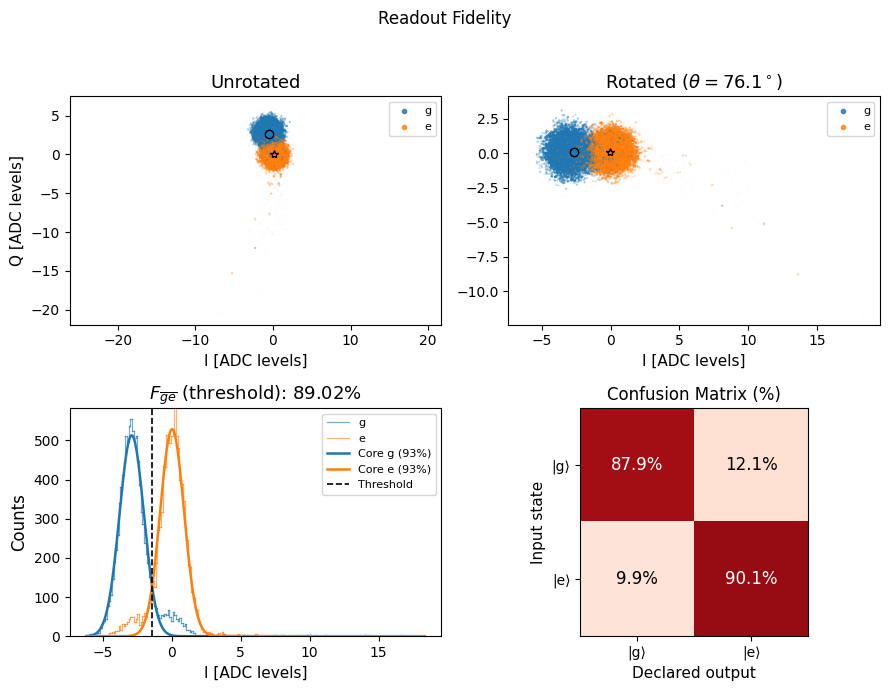

Rotation angle : 76.10 deg
Threshold Fid. : 89.015%
  g: core=93.0%  mean=-2.908  std=0.886
  e: core=93.1%  mean=0.021  std=0.861
Thresholds     : ['-1.412']
Confusion Matrix (%):
 [[87.9 12.1]
 [ 9.9 90.1]]


In [34]:
from QickworkspaceV2.experiments.setup import SingleShot_ge_opt
from QickworkspaceV2.experiments.setup import SingleShot_gef
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"


gain_axis = np.linspace(0.1, 0.15, 7)
length_axis = np.linspace(1, 6, 8)
sweep_para = { "gain":gain_axis, "length":length_axis}

SHOT = 3000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para)

### analyze and update config ###
length, gain = ssh_opt.analyze()

config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)


### run single shot with optimized parameters ###
config_all.update("res_phase", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

SHOT = 10000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)

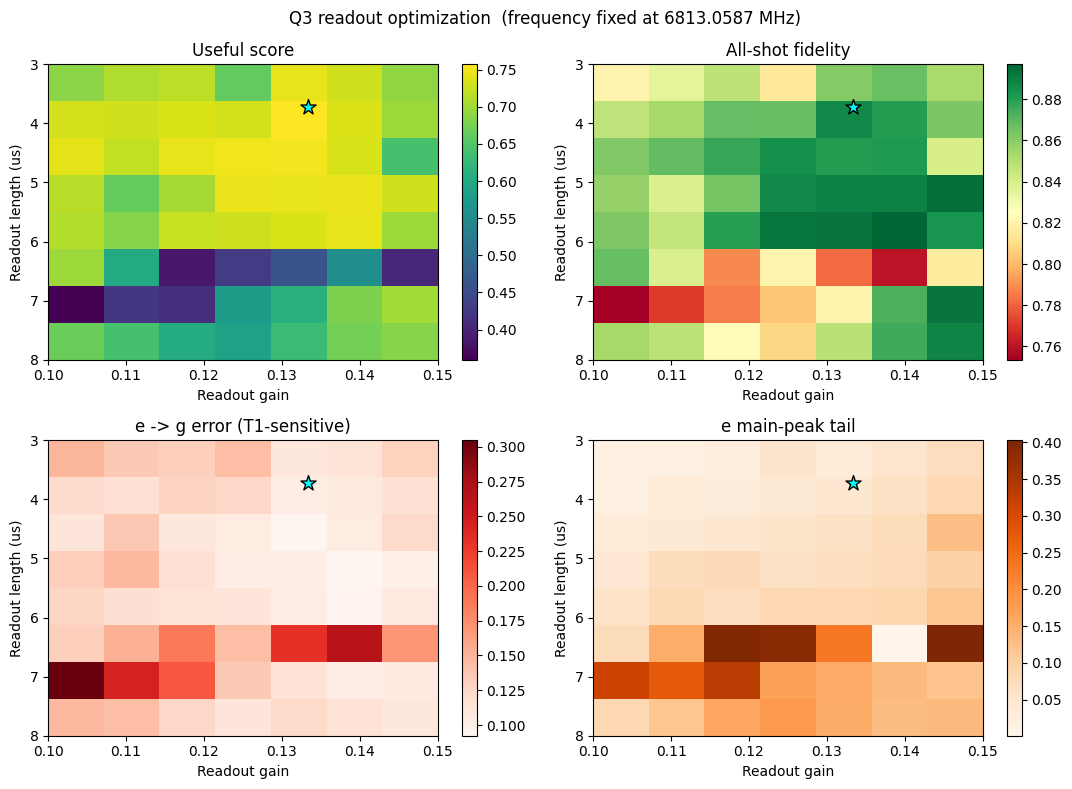

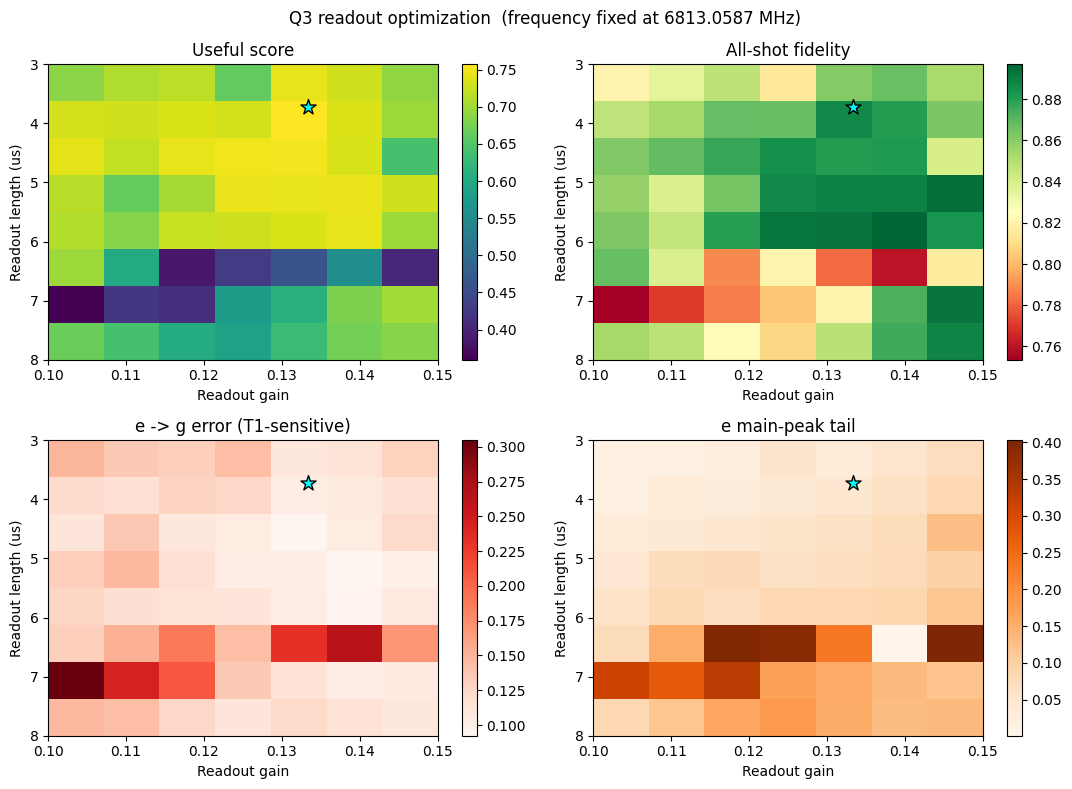

In [42]:
ssh_opt.plot_grid_analysis()

# EF State

## Resonator OneTone ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
    ]
)

onetone_ef = ResonatorSpec_ef(run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", fres["f_res[MHz]"], q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 3 averages. Fit is based on partial data.


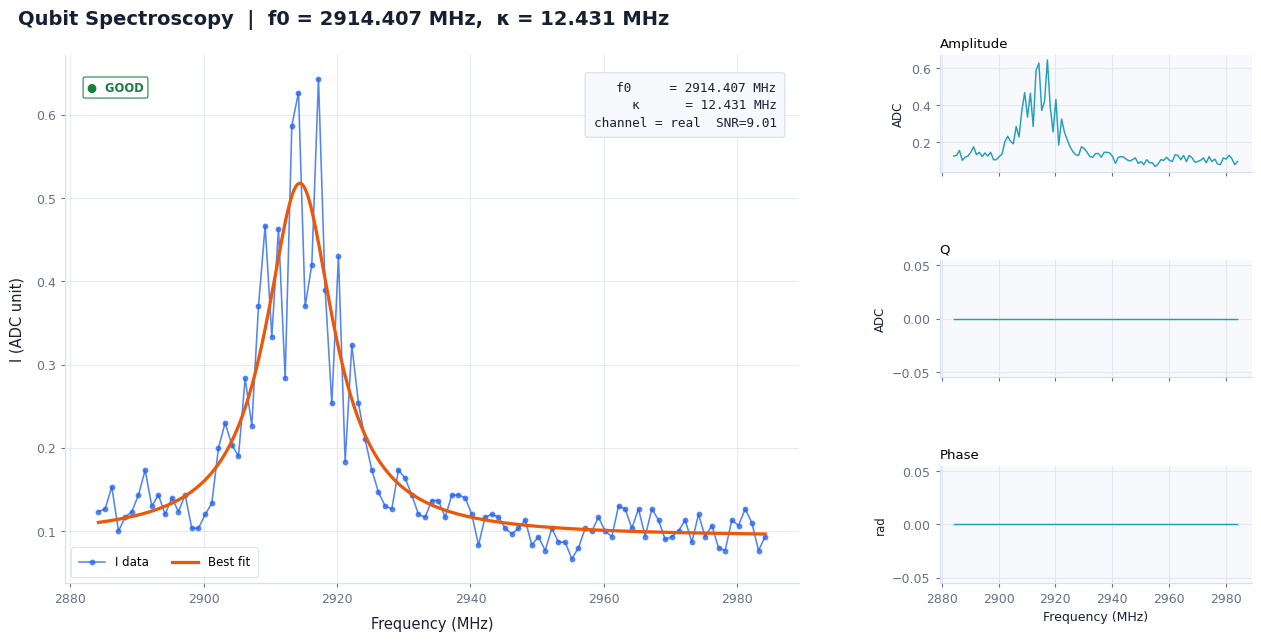

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s010_qubit_spec_ef_Q3_20260807T003200172537Z-FF0RBRDES3NNP.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s010_qubit_spec_ef_Q3_20260807T003200172537Z-FF0RBRDES3NNP.hdf5'

In [51]:
from QickworkspaceV2.experiments.qubit_ef import QubitSpecEf

center = config_all.get_qubit(qubit)["qb_freq_ge"] - 200
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 101

config_all.update("qb_ch_ef", 1, q_index=qubit)
config_all.update("nqz_qb_ef", 1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.3),
        ("qb_flat_top_length_ef", 2),
        ("ge_ref", True),
    ]
)

spectrum_ef = QubitSpecEf(run_cfg)
result_ef = spectrum_ef.run(10, plot_analysis=True)
f_ef = result_ef.scalar_result
config_all.update("qb_freq_ef", f_ef, q_index=qubit)
# config_all.update("qb_mixer_ef", f_ge, q_index=qubit)
spectrum_ef.saveLabber(qubit, config_all=config_all)

## Power Rabi ef

Experiment interrupted at 2 averages. Fit is based on partial data.


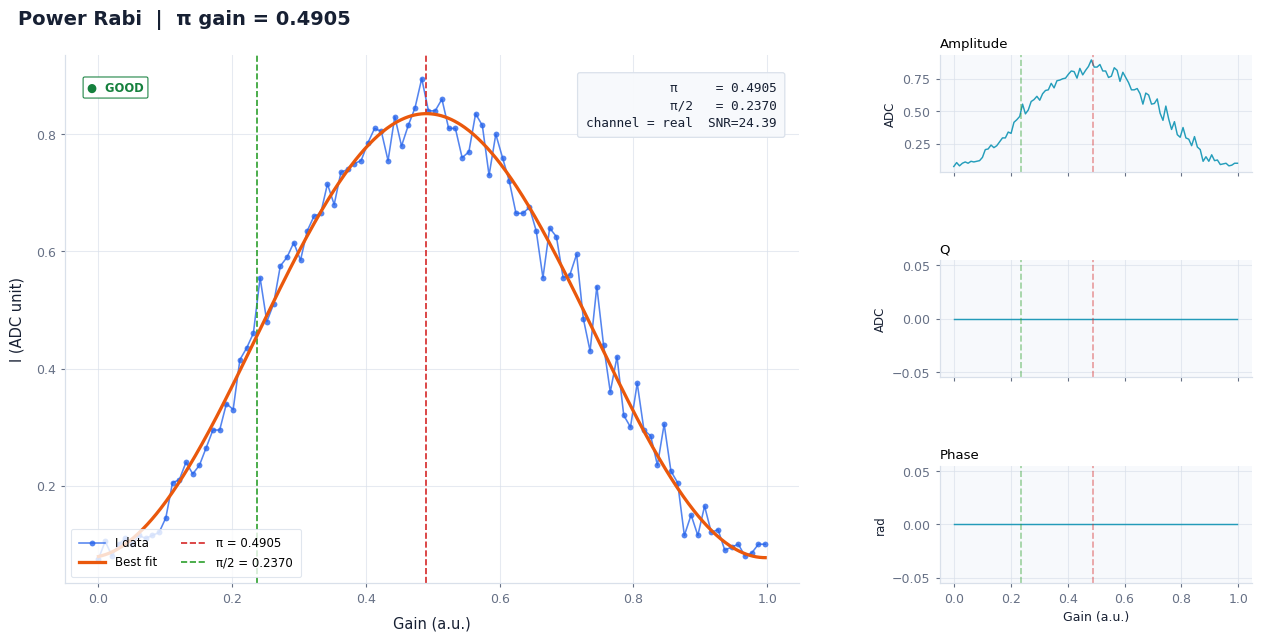

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s011_power_rabi_ef_Q3_20260807T003239591386Z-7S6811N4H2ADZ.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s011_power_rabi_ef_Q3_20260807T003239591386Z-7S6811N4H2ADZ.hdf5'

In [56]:
from QickworkspaceV2.experiments.qubit_ef import PowerRabiEf

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.02, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
    ]
)

prabi_ef = PowerRabiEf(run_cfg)
result_ef = prabi_ef.run(50, plot_analysis=True)
pi_gain_ef = result_ef["pi_gain"]
pi2_gain_ef = result_ef["pi2_gain"]
config_all.update("pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

## Qubit Temperature ef

[Temp] A_meas=0.0702  A_ref=0.6668  ratio=0.1053
[Temp] Estimated temperature: 77.41 mK
[Temp] Temperature error: +/- 7.39 mK
[Temp] 1-sigma temperature floor: 45.90 mK


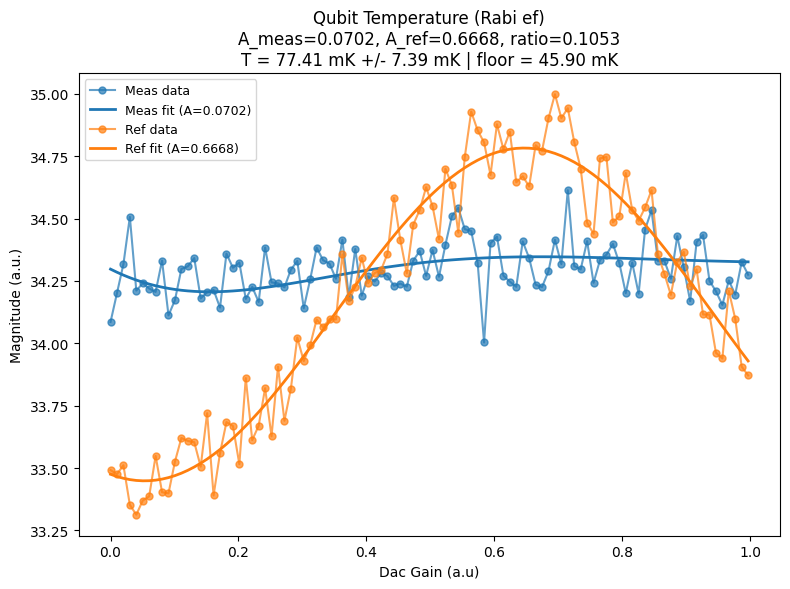

Data saved to D:\Labber_Data\Jay\test\2026\08\Data_0805\s013b_qubit_temp_ef_Q1_001


In [107]:
from QickworkspaceV2.experiments.qubit_ef import QubitTemp

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),

    ]
)

rabi_temp = QubitTemp(run_cfg)
rabi_temp.run(5, plot_analysis=True)
rabi_temp.saveLabber(qubit, config_all=config_all)

## Ramsey ef

Experiment interrupted at 2 averages. Fit is based on partial data.


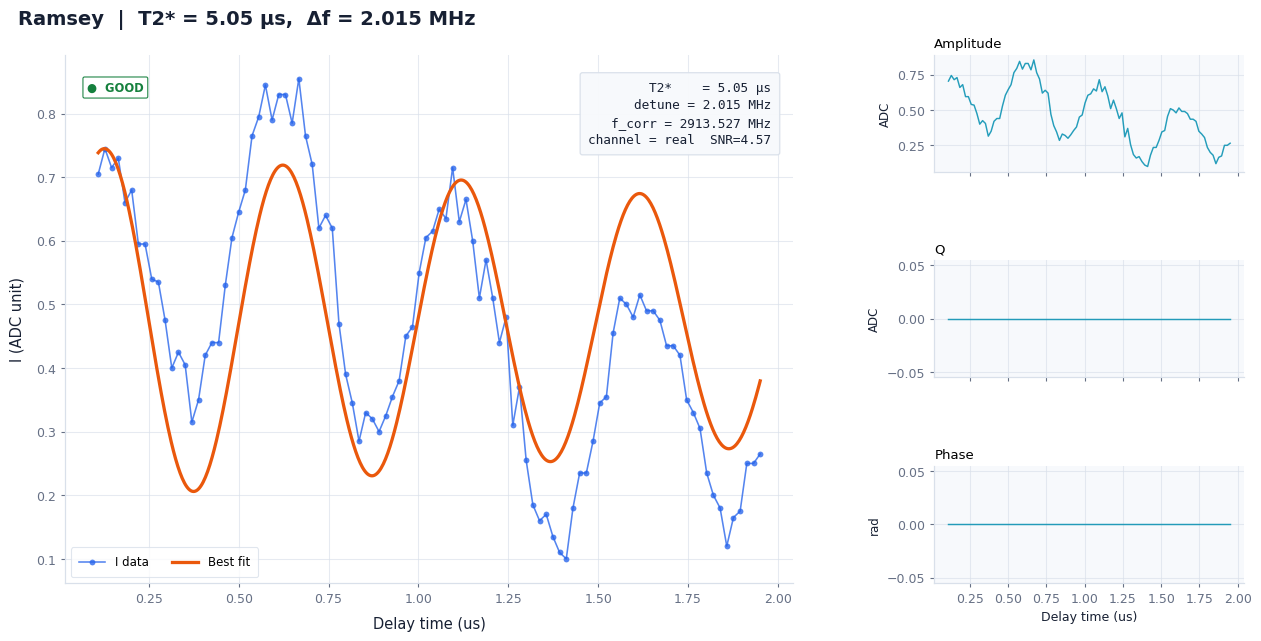

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s012_Ramsey_ef_Q3_20260807T003248725214Z-3ZCWJD2TXJ7N6.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s012_Ramsey_ef_Q3_20260807T003248725214Z-3ZCWJD2TXJ7N6.hdf5'

In [57]:
from QickworkspaceV2.experiments.qubit_ef import RamseyEf

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("virtual_detune", 2),
        ("ge_ref", True),
    ]
)

t2r_ef = RamseyEf(run_cfg)
t2r_ef.run(100, plot_analysis=True)
t2r_ef.saveLabber(qubit, config_all=config_all)

In [55]:
config_all.update("qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune 0.86962MHz


## T1 ef

Experiment interrupted at 3 averages. Fit is based on partial data.


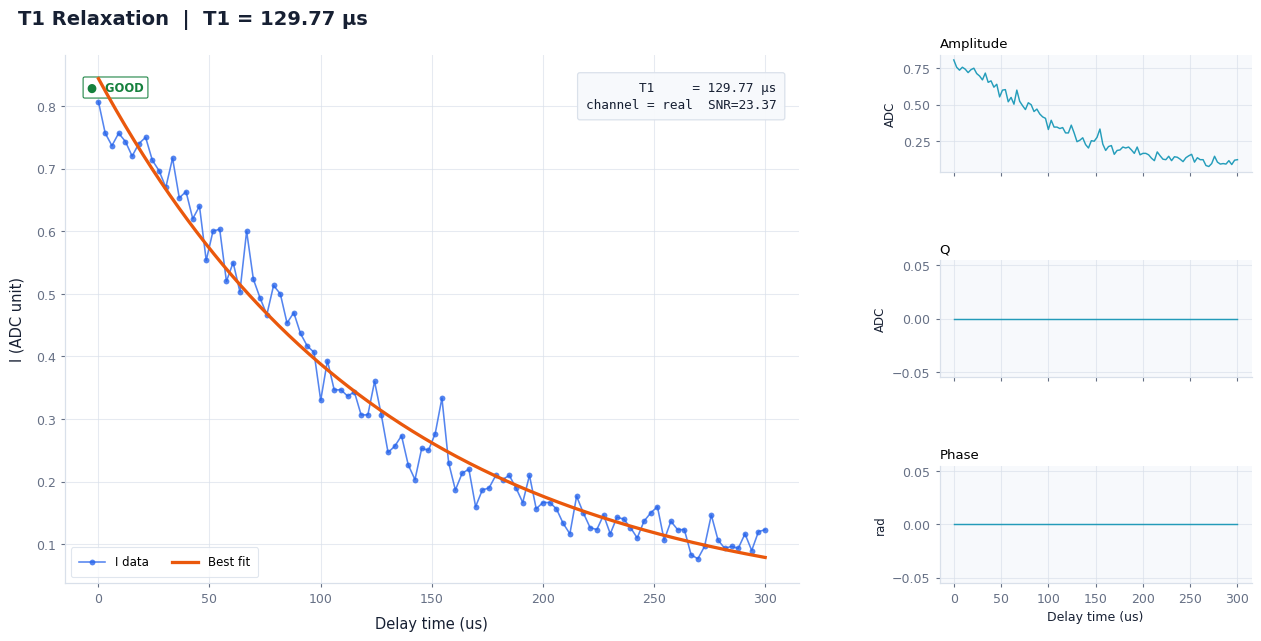

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s013_T1_ef_Q3_20260807T003323340367Z-AMXJQVY1HSE0T.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s013_T1_ef_Q3_20260807T003323340367Z-AMXJQVY1HSE0T.hdf5'

In [60]:
from QickworkspaceV2.experiments.qubit_ef import T1Ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 300  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
    ]
)

t1_ef = T1Ef(run_cfg)
t1_ef.run(50, plot_analysis=True)
t1_ef.saveLabber(qubit, config_all=config_all)

## Single Shot gef (ef)

  0%|          | 0/20000 [00:00<?, ?it/s]

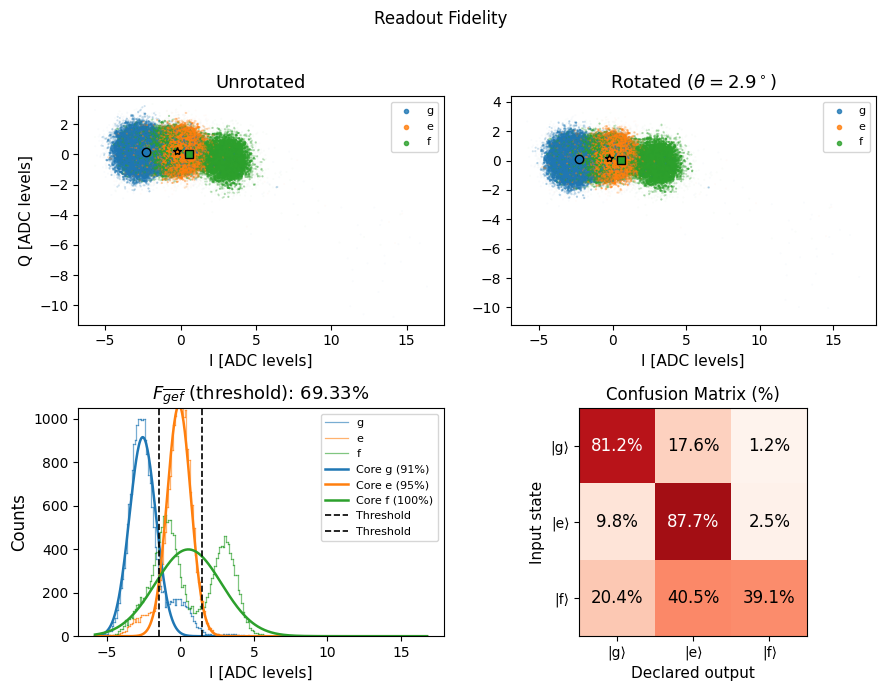

Rotation angle : 2.93 deg
Threshold Fid. : 69.330%
  g: core=91.4%  mean=-2.564  std=0.900
  e: core=94.7%  mean=-0.096  std=0.804
  f: core=100.0%  mean=0.541  std=2.258
Thresholds     : ['-1.462', '1.501']
Confusion Matrix (%):
 [[81.2 17.6  1.2]
 [ 9.8 87.7  2.5]
 [20.4 40.5 39.1]]
Current data file: D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s000_singleshot_gef_Q3_001


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s000_singleshot_gef_Q3_20260807T003342516618Z-0RZ7GG4FSE9VD.hdf5'

In [61]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = 'drag'

SHOT = 20000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)
ssh.saveLabber(qubit, config_all=config_all)

# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

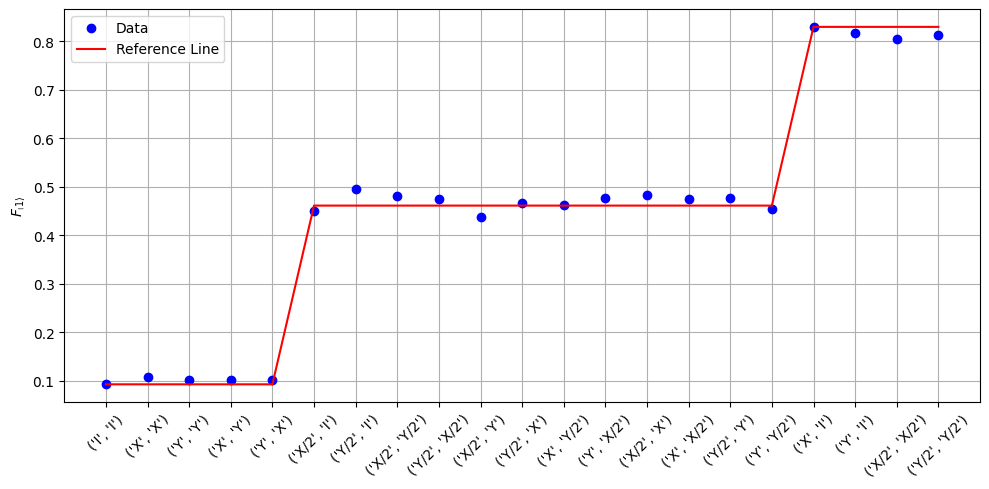

In [17]:
from QickworkspaceV2.experiments.characterization import AllXY

run_cfg = config_all.get_qubit(qubit)

allxy = AllXY(run_cfg)
allxy.run(10)
allxy.plot()

### Drag AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

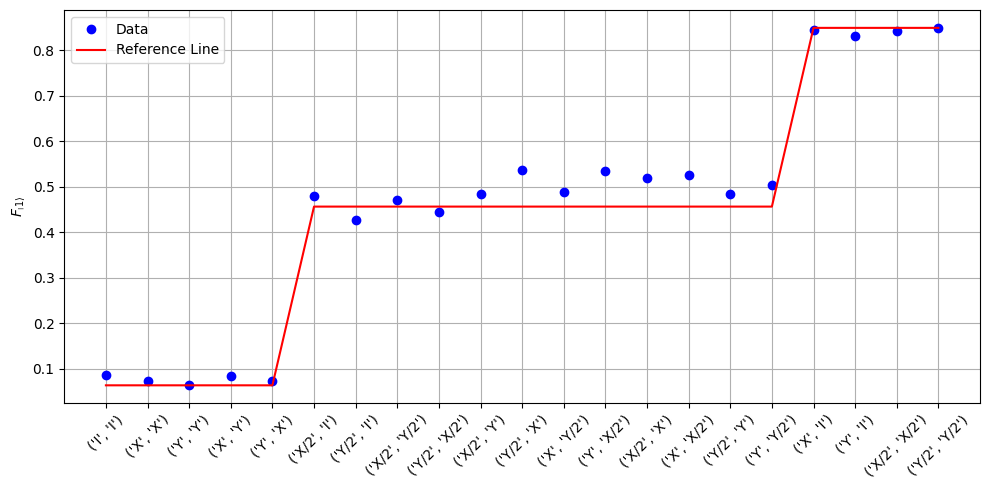

In [65]:
from QickworkspaceV2.experiments.characterization import AllXY

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("pulse_type", "drag"),
    ]
)
allxy = AllXY(run_cfg)
allxy.run(10)
allxy.plot()

## State Tomography

Calibrating |0⟩ state...
Calibrating |1⟩ state...
IQ Ground: (4.972558177379984-1.1562392188771358j), IQ Excited: (7.062102522375916-1.2602766476810414j)


Tomography (x90):   0%|          | 0/3 [00:00<?, ?it/s]


<X>=-0.1765, <Y>=-1.0000, <Z>=0.0867
Purity: 1.00000


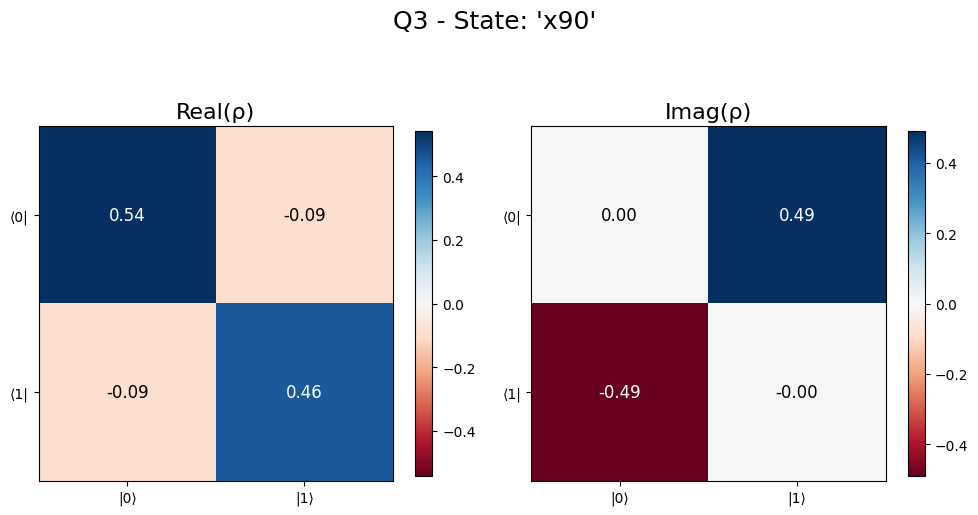

c:\Users\cluster\Desktop\QickworksaceV2_proj-main\QickworkspaceV2\experiments\characterization\state_tomography.py:352: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


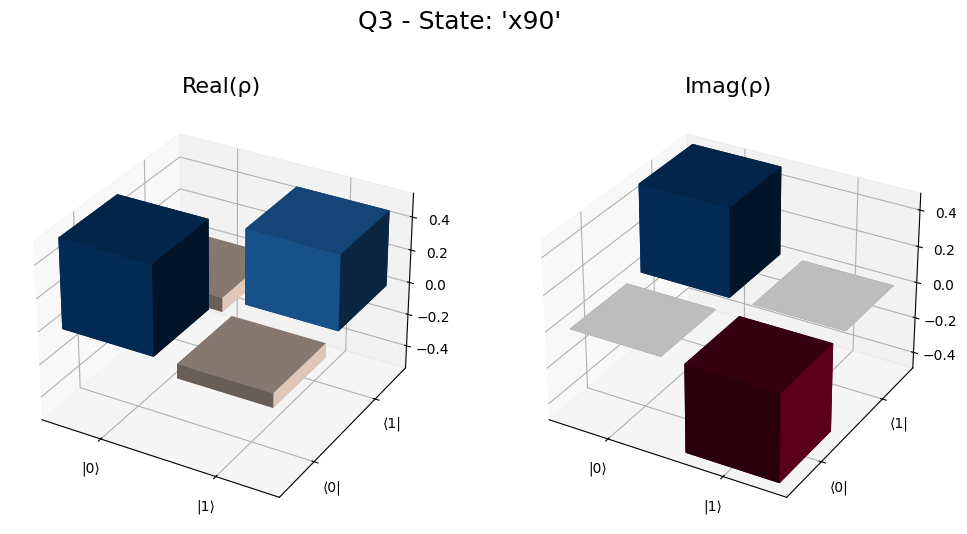

(<Figure size 1200x600 with 2 Axes>, None)

In [177]:
from QickworkspaceV2.experiments.characterization import Tomography

pyavg = 5

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"
tomo = Tomography(run_cfg)
tomo.run(py_avg=pyavg, prep_pulse_name="x90")
tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking

AutoRB:   0%|          | 0/3 [00:00<?, ?it/s]

[RB] QICK threshold=-1.2852000004936073; reporting ground survival P(g)=1-P(I>threshold).


Compile Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

Software Average:   0%|          | 0/1 [00:00<?, ?it/s]

Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

[fitrb] p=0.979389  a=0.4241  b=0.5041
[fitrb] σ(p)=1.72e-03  σ(a)=1.51e-02  σ(b)=7.51e-03
[fitrb] p=0.990601  a=0.3319  b=0.5143
[fitrb] σ(p)=1.87e-03  σ(a)=2.34e-02  σ(b)=2.41e-02

--- Reference RB ---
  p   = 99.060083 ± 0.186671 %
  EPC = 0.469958 ± 0.093335 %
[fitrb] p=0.988348  a=0.4084  b=0.5164
[fitrb] σ(p)=1.59e-03  σ(a)=2.01e-02  σ(b)=1.75e-02

--- IRB (X) ---
  p   = 98.834790 ± 0.159448 %
  EPC = 0.582605 ± 0.079724 %
  Gate 'X': F = 99.8863%, EPC = 0.1137 ± 0.1238 %
[fitrb] p=0.979389  a=0.4241  b=0.5041
[fitrb] σ(p)=1.72e-03  σ(a)=1.51e-02  σ(b)=7.51e-03

--- IRB (X/2) ---
  p   = 97.938856 ± 0.172176 %
  EPC = 1.030572 ± 0.086088 %
  Gate 'X/2': F = 99.4341%, EPC = 0.5659 ± 0.1274 %


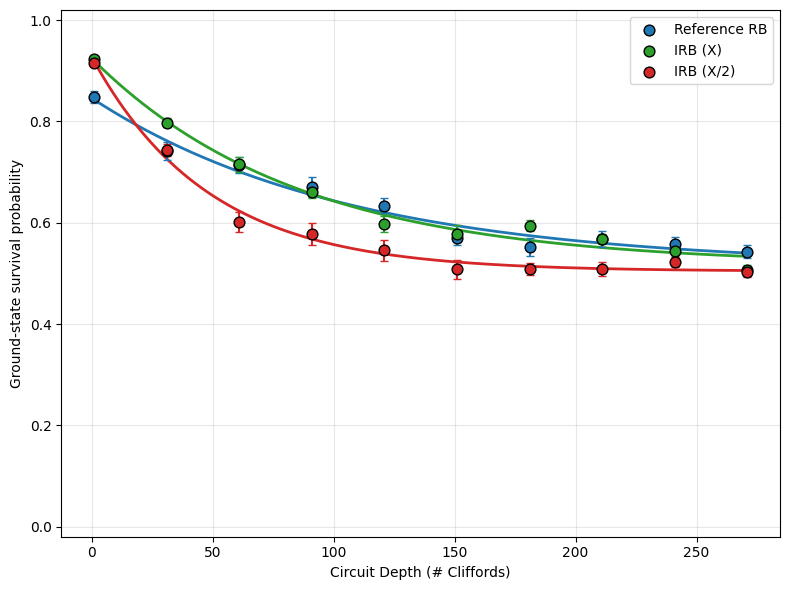

RB data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s015_RB_ref_Q3_001
RB data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s015_RB_X_Q3_001
RB data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s015_RB_halfX_Q3_001
AutoRB Summary
  ref         EPC=0.46996%
  X           F=99.8863%  EPC=0.11372%
  X/2         F=99.4341%  EPC=0.56593%


In [66]:
from QickworkspaceV2.experiments.characterization import AutoRB

run_cfg = config_all.get_qubit(qubit)
run_cfg["pulse_type"] = "drag"
run_cfg['reps'] = 1000
run_cfg['relax_delay'] = 200
# run_cfg['threshold'] = None
auto = AutoRB(run_cfg)
interleaved = ["X", "X/2"]
auto.run(
    py_avg=1,
    max_circuit_depth=300,
    delta_clifford=30,
    number_sample=30,
    interleaved_gates=interleaved,
    # iq_process="real",
)
auto.plot()
auto.saveLabber(qubit, config_all=config_all)
print(auto.summary())

In [122]:
auto.saveLabber(qubit, config_all=config_all)


Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick_gui\Lib\site-packages\IPython\core\interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_65860\2414173931.py", line 1, in <module>
    auto.saveLabber(qubit, config_all=config_all)
  File "c:\Users\cluster\Desktop\QickworksaceV2_proj-main\QickworkspaceV2\experiments\characterization\rb.py", line 652, in saveLabber
    rb.saveLabber(qb_idx, config_all=config_all, yoko_value=yoko_value, title=label)
  File "c:\Users\cluster\Desktop\QickworksaceV2_proj-main\QickworkspaceV2\experiments\characterization\rb.py", line 424, in saveLabber
    file_path = get_next_filename_labber(save_dir, expt_name, yoko_value)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\cluster\Desktop\QickworksaceV2_proj-main\QickworkspaceV2\tools\system_tool.py", line 45, in get_next_filename_labber
   

AutoRB:   0%|          | 0/3 [00:00<?, ?it/s]

[RB] QICK threshold=-2.8060836900626; reporting ground survival P(g)=1-P(I>threshold).


Compile Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

Software Average:   0%|          | 0/1 [00:00<?, ?it/s]

Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

[fitrb] p=0.986458  a=0.4002  b=0.4914
[fitrb] σ(p)=6.32e-04  σ(a)=8.00e-03  σ(b)=3.40e-03
[fitrb] p=0.989103  a=0.3033  b=0.5040
[fitrb] σ(p)=8.37e-04  σ(a)=9.91e-03  σ(b)=4.82e-03

--- Reference RB ---
  p   = 98.910306 ± 0.083719 %
  EPC = 0.544847 ± 0.041860 %
[fitrb] p=0.991240  a=0.4239  b=0.4759
[fitrb] σ(p)=9.44e-04  σ(a)=1.86e-02  σ(b)=1.08e-02

--- IRB (Y) ---
  p   = 99.123991 ± 0.094442 %
  EPC = 0.438005 ± 0.047221 %
  Gate 'Y': F = 100.1080%, EPC = -0.1080 ± 0.0639 %
[fitrb] p=0.986458  a=0.4002  b=0.4914
[fitrb] σ(p)=6.32e-04  σ(a)=8.00e-03  σ(b)=3.40e-03

--- IRB (Y/2) ---
  p   = 98.645776 ± 0.063228 %
  EPC = 0.677112 ± 0.031614 %
  Gate 'Y/2': F = 99.8663%, EPC = 0.1337 ± 0.0529 %


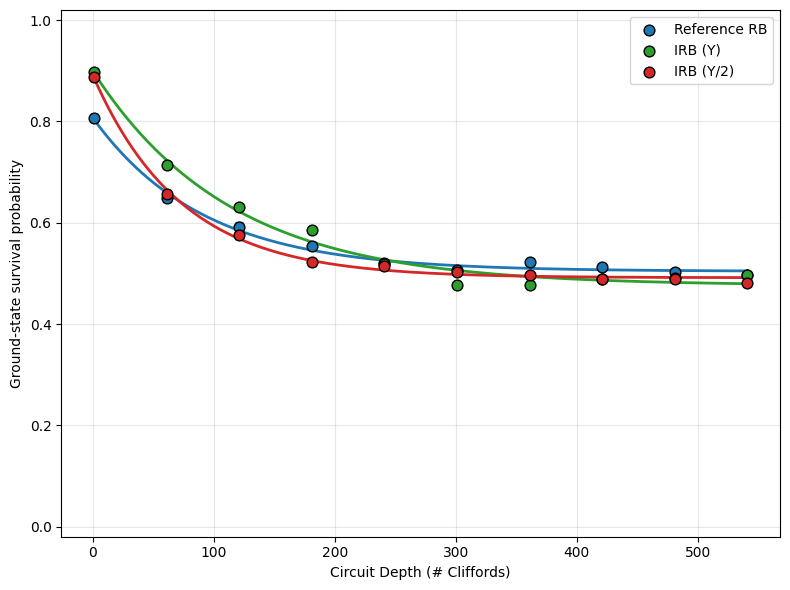

RB data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s015_RB_ref_Q3_001
RB data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s015_RB_Y_Q3_001
RB data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0806\s015_RB_halfY_Q3_001
AutoRB Summary
  ref         EPC=0.54485%
  Y           F=100.1080%  EPC=-0.10802%
  Y/2         F=99.8663%  EPC=0.13372%


In [120]:
from QickworkspaceV2.experiments.characterization import AutoRB

run_cfg = config_all.get_qubit(qubit)
run_cfg["pulse_type"] = "drag"
run_cfg['reps'] = 1500
# run_cfg['threshold'] = None
auto = AutoRB(run_cfg)
interleaved = ["Y", "Y/2"]
auto.run(
    py_avg=1,
    max_circuit_depth=600,
    delta_clifford=60,
    number_sample=50,
    interleaved_gates=interleaved,
    # iq_process="real",
)
auto.plot()
auto.saveLabber(qubit, config_all=config_all)
print(auto.summary())

In [ ]:
from QickworkspaceV2.experiments.characterization import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

py_avg = 5
max_circuit_depth = 400
delta_clifford = 40
number_sample = 30

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
# interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
interleaved_gates_to_test = ["X/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)

# Drag

Scan interrupted at Iterations (N): 14.0, DRAG Parameter (α): -2.0
Interrupted at avg 5.

[DRAG Sum] Optimal α = 2.747843)


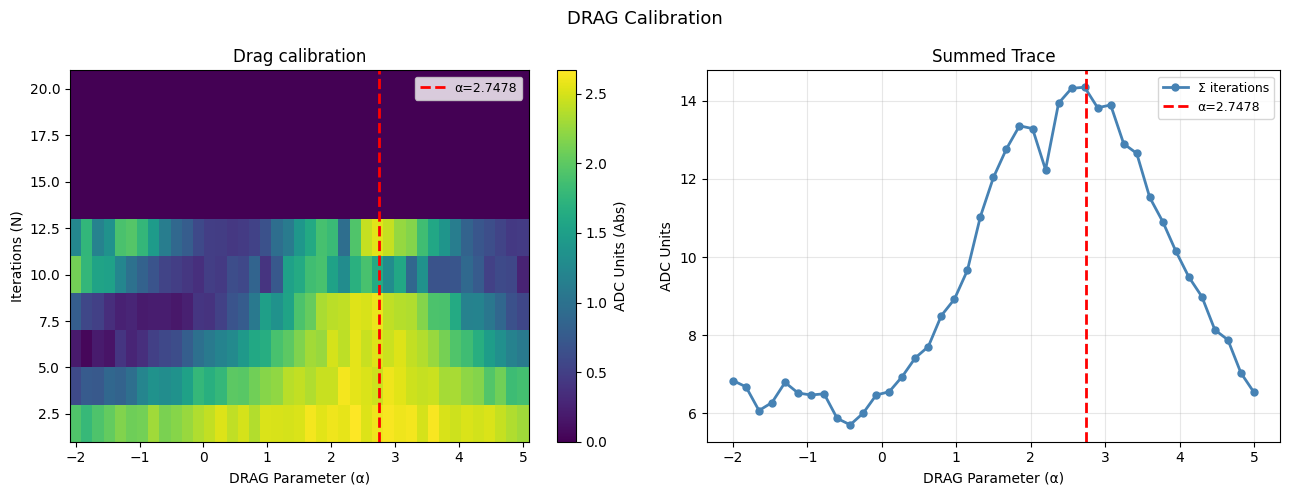

Data saved to D:\Labber_Data\Jay\purcell_tmon\withTWPA\2026\08\Data_0807\s005a_drag_ge_Q3_20260807T003859418023Z-4T9D3MFQF0SSQ.hdf5


'D:\\Labber_Data\\Jay\\purcell_tmon\\withTWPA\\2026\\08\\Data_0807\\s005a_drag_ge_Q3_20260807T003859418023Z-4T9D3MFQF0SSQ.hdf5'

In [64]:
from QickworkspaceV2.experiments.qubit_ge import DragCalibration

run_cfg = config_all.get_qubit(qubit)
run_cfg['threshold'] = None
run_cfg.update(
    [
        # Alpha
        ("alpha_start", -2),
        ("alpha_stop", 5),
        ("alpha_steps", 41),
        # Iterations
        ("iteration_start", 2),
        ("iteration_stop", 20),
        ("iteration_step", 2),
    ]
)

drag_cal = DragCalibration(run_cfg)
fit_results = drag_cal.run(py_avg=5)

config_all.update("drag_alpha", fit_results["optimal_alpha"], q_index=qubit)
drag_cal.saveLabber(qubit, config_all=config_all)

# Active Reset Rabi A/B Test


  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

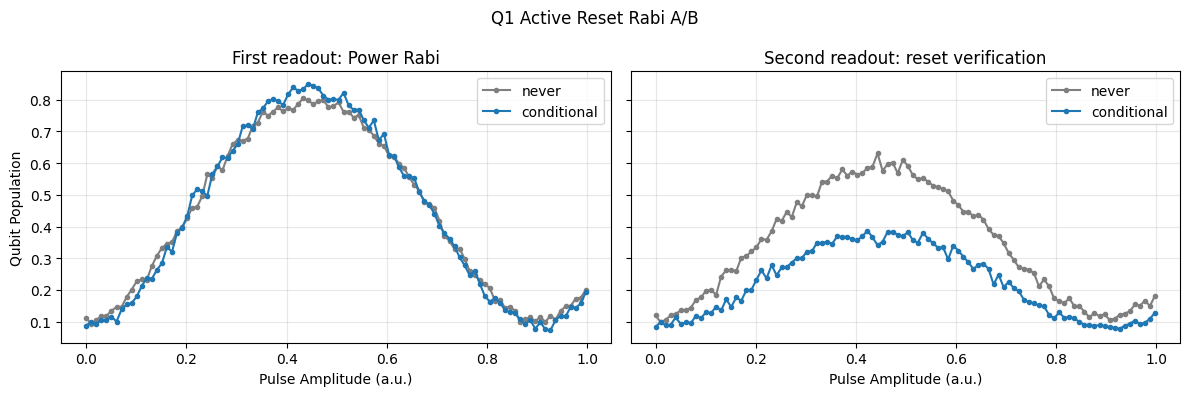

In [43]:
from qick.asm_v2 import QickSweep1D
from QickworkspaceV2.experiments.qubit_ge import ActiveResetRabi

START_GAIN = 0.0
STOP_GAIN = 1.0
STEPS = 100
PY_AVG = 1

ab_experiments = {}
ab_results = {}
for reset_mode in ("never", "conditional"):
    run_cfg = config_all.get_qubit(qubit)  # current Q1 calibration
    run_cfg.update(
        [
            ("steps", STEPS),
            ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
            ("reset_mode", reset_mode),
            ("reset_component", "I"),
            # Current Q1 rotated single-shot has I_e > I_g.
            ("reset_excited_if", ">="),
            ("read_wait", 0.2),  # resync timing validated on current Q1 [us]
            ("feedback_slack", 0.05),
            ("reset_post_delay", 0.05),
            # Intentionally short: expose the inter-shot reset benefit.
            ("relax_delay", 100.0),
            ("reps", 1000)
        ]
    )
    experiment = ActiveResetRabi(run_cfg)
    result = experiment.run(py_avg=PY_AVG, plot_analysis=False)
    ab_experiments[reset_mode] = experiment
    ab_results[reset_mode] = result

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for reset_mode, color in (("never", "tab:gray"), ("conditional", "tab:blue")):
    experiment = ab_experiments[reset_mode]
    result = ab_results[reset_mode]
    axes[0].plot(
        result.x_axis,
        np.asarray(experiment.pre_reset_population),
        "o-",
        ms=3,
        color=color,
        label=reset_mode,
    )
    axes[1].plot(
        result.x_axis,
        np.asarray(experiment.post_reset_population),
        "o-",
        ms=3,
        color=color,
        label=reset_mode,
    )

axes[0].set_title("First readout: Power Rabi")
axes[1].set_title("Second readout: reset verification")
for ax in axes:
    ax.set_xlabel("Pulse Amplitude (a.u.)")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Qubit Population")
fig.suptitle("Q1 Active Reset Rabi A/B")
fig.tight_layout()

# Active Reset Feedback Timing Test (Current Q1 Config)


Qubit                  : Q3
tProc clock            : 430.080 MHz
legacy wait_all(200)   : 0.465030 us
current relax_delay    : 200 us
threshold              : -14.161722622773732
res_phase              : -78.77487170542332 deg
pi_gain_ge             : 0.743776
timing sweep           : [0.05, 0.1, 0.2, 0.3, 0.46503, 0.5] us


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]


read_wait [us] | post mean | post peak | post span
-----------------------------------------------------
      0.050000 |    0.4622 |    0.7067 |    0.5833
      0.100000 |    0.4633 |    0.6967 |    0.5867
      0.200000 |    0.4791 |    0.7700 |    0.6900
      0.300000 |    0.4453 |    0.7033 |    0.5900
      0.465030 |    0.4374 |    0.7000 |    0.6033
      0.500000 |    0.4477 |    0.7100 |    0.6067


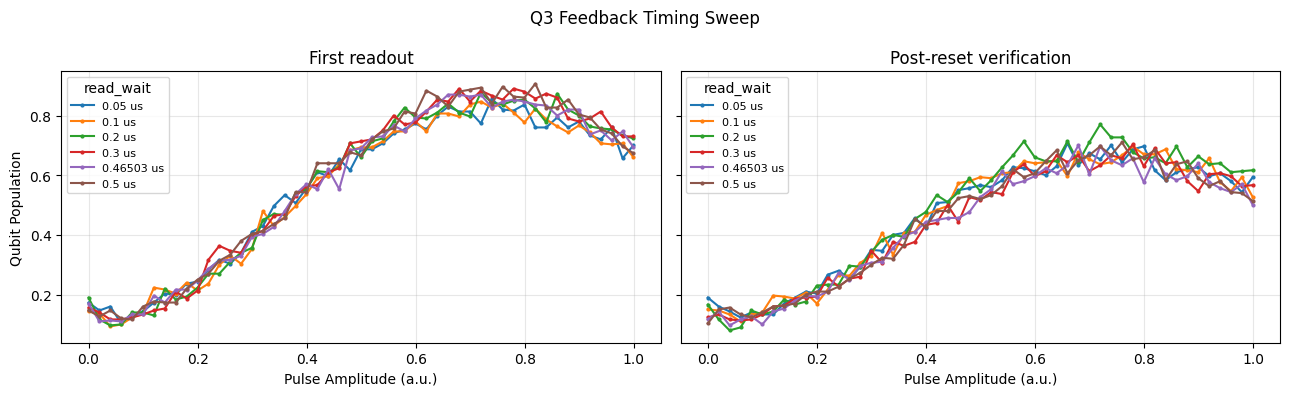

In [23]:
from qick.asm_v2 import QickSweep1D
from QickworkspaceV2.experiments.qubit_ge import ActiveResetRabi

# Use the live, currently calibrated Q1 configuration.
base_cfg = config_all.get_qubit(qubit)
f_tproc_mhz = float(soccfg["tprocs"][0]["f_time"])
legacy_wait_us = 200.0 / f_tproc_mhz
READ_WAITS_US = sorted(
    set(round(value, 6) for value in [
        0.05,
        0.10,
        0.20,
        0.3,
        legacy_wait_us,
        0.5,

    ])
)

print(f"Qubit                  : {qubit}")
print(f"tProc clock            : {f_tproc_mhz:.3f} MHz")
print(f"legacy wait_all(200)   : {legacy_wait_us:.6f} us")
print(f"current relax_delay    : {base_cfg['relax_delay']} us")
print(f"threshold              : {base_cfg['threshold']}")
print(f"res_phase              : {base_cfg['res_phase']} deg")
print(f"pi_gain_ge             : {base_cfg['pi_gain_ge']}")
print(f"timing sweep           : {READ_WAITS_US} us")

START_GAIN = 0.0
STOP_GAIN = 1.0
STEPS = 51
PY_AVG = 3

feedback_timing_runs = {}
for read_wait_us in READ_WAITS_US:
    run_cfg = config_all.get_qubit(qubit)
    run_cfg.update(
        [
            ("steps", STEPS),
            ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
            ("reset_mode", "conditional"),
            ("reset_component", "I"),
            ("reset_excited_if", ">="),
            ("read_wait", read_wait_us),
            ("feedback_slack", 0.05),
            ("reset_post_delay", 0.05),
        ]
    )
    experiment = ActiveResetRabi(run_cfg)
    result = experiment.run(py_avg=PY_AVG, plot_analysis=False)
    feedback_timing_runs[read_wait_us] = {
        "experiment": experiment,
        "result": result,
        "pre": np.asarray(experiment.pre_reset_population),
        "post": np.asarray(experiment.post_reset_population),
    }

print("\nread_wait [us] | post mean | post peak | post span")
print("-" * 53)
for read_wait_us, run in feedback_timing_runs.items():
    post = run["post"]
    print(
        f"{read_wait_us:14.6f} | {np.mean(post):9.4f} | "
        f"{np.max(post):9.4f} | {np.ptp(post):9.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for read_wait_us, run in feedback_timing_runs.items():
    x = run["result"].x_axis
    label = f"{read_wait_us:g} us"
    axes[0].plot(x, run["pre"], "o-", ms=2, label=label)
    axes[1].plot(x, run["post"], "o-", ms=2, label=label)

axes[0].set_title("First readout")
axes[1].set_title("Post-reset verification")
for ax in axes:
    ax.set_xlabel("Pulse Amplitude (a.u.)")
    ax.grid(alpha=0.3)
    ax.legend(title="read_wait", fontsize=8)
axes[0].set_ylabel("Qubit Population")
fig.suptitle(f"{qubit} Feedback Timing Sweep")
fig.tight_layout()